# Systematic offline S/N-map peak-finder comparison

This notebook evaluates exactly five algorithms on the same selected PIRATE
tree: (0) the adaptive bank of bowties, (1) a union bowtie, (2) a discrete
convex-hull bowtie, (3) the bowtie-derived bounding rectangle, and (4) an
8-connected-component maximum.

The first four are local-maximum methods: the full, unthresholded S/N map is
maximum-filtered first, then pixels satisfying `(S == filtered) & (S > T)`
are retained. The connected-component method is intentionally different:
it thresholds first, labels 2-D components, and retains exactly one original
S/N maximum per component. No grouping across trees is attempted.

Map-sized filtering, labeling, candidate extraction, and sorting use
CuPy/CuPyX. NumPy remains limited to ASDF I/O, small footprint geometry,
PIRATE's CPU decoder, compact diagnostics, and Matplotlib visualization.

In [1]:
# Parameters: edit this cell, then Run All.
from pathlib import Path

ASDF_PATH = Path("/home/mtrudu/chordsim/test/frame_b100_t0_snrmap.asdf")
GPU_DEVICE = 0
TREE_INDEX = 0
SNR_THRESHOLD = 10.0

# Shared by the two sliding-window methods below.
# "exclude": a footprint that crosses the map boundary sees +inf, so
# its centre is rejected. "include": outside the map is -inf.
EDGE_POLICY = "exclude"

ADAPTIVE_DM_REACH = 8
ADAPTIVE_WAIST_BINS = 1.0
PATCH_HALF_SIZE = (32, 32)  # (DM bins, time bins)
MAX_TABLE_ROWS = 20

## 1. Load and validate one tree

Saved `snr` and `argmax` arrays both have axes
`(coarse DM index, coarse time index)`. For every pixel,
`snr[idm, itime]` and `argmax[idm, itime]` describe the same winning
trial. The file contains a single beam; beam identity is metadata, not
an array axis. Trees are separate entries because each may have a
different DM/time grid.

The file is opened lazily. Shapes and dtypes of all trees are checked
from their ASDF array descriptors, but only the selected tree is copied
into owned host arrays before the file is closed.

In [2]:
import html

import asdf
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np
import yaml
from cupyx.scipy.ndimage import maximum_filter as gpu_maximum_filter
from IPython.display import display

from pirate_frb import DedispersionPlan


class Table:
    # Small dependency-free table for notebook display.
    def __init__(self, data=None, columns=None):
        if data is None:
            rows = []
        elif isinstance(data, dict):
            keys = list(data)
            lengths = [
                1 if isinstance(value, str) or np.isscalar(value) else len(value)
                for value in data.values()
            ]
            nrows = max(lengths, default=0)
            columns_data = [
                [value] * nrows
                if isinstance(value, str) or np.isscalar(value)
                else list(value)
                for value in data.values()
            ]
            if any(len(values) != nrows for values in columns_data):
                raise ValueError("Table columns have incompatible lengths")
            rows = [dict(zip(keys, values)) for values in zip(*columns_data)]
        else:
            rows = list(data)
        self.rows = rows
        self.columns = list(columns) if columns is not None else (list(rows[0]) if rows else [])

    def head(self, n=5):
        return Table(self.rows[:n], self.columns)

    def _repr_html_(self):
        header = "".join(f"<th>{html.escape(str(column))}</th>" for column in self.columns)
        body = "".join(
            "<tr>" + "".join(
                f"<td>{html.escape(str(row.get(column, chr(160))))}</td>" for column in self.columns
            ) + "</tr>" for row in self.rows
        )
        return f"<div><table><thead><tr>{header}</tr></thead><tbody>{body}</tbody></table></div>"

EXPECTED_FORMAT = "pirate_frb.offline_dedisperser_snr_maps"
EXPECTED_VERSION = 2

if EDGE_POLICY not in {"exclude", "include"}:
    raise ValueError("EDGE_POLICY must be 'exclude' or 'include'")
if not ASDF_PATH.is_file():
    raise FileNotFoundError(ASDF_PATH)

with asdf.open(ASDF_PATH, lazy_load=True) as af:
    root = af.tree
    if root.get("format") != EXPECTED_FORMAT:
        raise ValueError(f"Not a PIRATE offline S/N-map ASDF: {root.get('format')!r}")
    if int(root.get("format_version", -1)) != EXPECTED_VERSION:
        raise ValueError(
            f"Expected format version 2 with argmax maps; got "
            f"{root.get('format_version')!r}. Regenerate with the updated "
            "run_offline_dedisperser --save."
        )

    config_yaml = str(root["config_yaml"])
    plan_yaml = str(root["plan_yaml"])
    source = dict(root["source"])
    time_sample_ms = float(root["time_sample_ms"])
    nt_in = int(root["nt_in"])
    nfreq = int(root["nfreq"])
    plan = DedispersionPlan.make_incomplete_plan_from_yaml(config_yaml, plan_yaml)

    trees = root["trees"]
    if len(trees) != len(plan.trees):
        raise ValueError(f"Saved tree count {len(trees)} != plan tree count {len(plan.trees)}")
    if not 0 <= TREE_INDEX < len(trees):
        raise IndexError(f"TREE_INDEX={TREE_INDEX}; file has {len(trees)} trees")

    tree_rows = []
    for itree, (saved_tree, plan_tree) in enumerate(zip(trees, plan.trees)):
        if "snr" not in saved_tree or "argmax" not in saved_tree:
            raise ValueError(f"Tree {itree} does not contain both snr and argmax")
        snr_shape = tuple(saved_tree["snr"].shape)
        argmax_shape = tuple(saved_tree["argmax"].shape)
        expected_shape = (int(plan_tree.ndm_out), int(plan_tree.nt_out))
        if snr_shape != expected_shape or argmax_shape != expected_shape:
            raise ValueError(
                f"Tree {itree}: snr={snr_shape}, argmax={argmax_shape}, "
                f"expected={expected_shape}"
            )
        if np.dtype(saved_tree["argmax"].dtype) != np.dtype(np.uint32):
            raise TypeError(f"Tree {itree} argmax dtype is {saved_tree['argmax'].dtype}, not uint32")
        tree_rows.append(
            {
                "tree": itree,
                "shape_(DM,time)": snr_shape,
                "snr_dtype": str(saved_tree["snr"].dtype),
                "argmax_dtype": str(saved_tree["argmax"].dtype),
                "dm_min": float(saved_tree["dm_min"]),
                "dm_max": float(saved_tree["dm_max"]),
            }
        )

    selected = trees[TREE_INDEX]
    snr_cpu = np.array(selected["snr"], copy=True)
    argmax_cpu = np.array(selected["argmax"], dtype=np.uint32, copy=True)
    dm_min = float(selected["dm_min"])
    dm_max = float(selected["dm_max"])

if snr_cpu.shape != argmax_cpu.shape or argmax_cpu.dtype != np.uint32:
    raise AssertionError("Selected snr/argmax arrays lost their one-to-one shape or uint32 dtype")

config_dict = yaml.safe_load(config_yaml)
reference_freq_mhz = float(config_dict["zone_freq_edges"][0])
sample_time_s = time_sample_ms * 1.0e-3
chunk_duration_s = sample_time_s * nt_in
ndm, ntime = snr_cpu.shape
dm_bin = (dm_max - dm_min) / ndm
time_bin_s = chunk_duration_s / ntime

print(f"file: {ASDF_PATH}")
print(f"source: beam={source['beam_id']}, chunk={source['time_chunk_index']}, "
      f"intensity={source['filename']}")
print(f"input: nfreq={nfreq}, nt_in={nt_in}, sample={time_sample_ms:.6f} ms")
print(f"selected tree: {TREE_INDEX}; shape={snr_cpu.shape}; "
      f"snr={snr_cpu.dtype}; argmax={argmax_cpu.dtype}")
display(Table(tree_rows))

file: /home/mtrudu/chordsim/test/frame_b100_t0_snrmap.asdf
source: beam=100, chunk=0, intensity=/home/mtrudu/chordsim/test/frame_b100_t0.asdf
input: nfreq=28160, nt_in=2048, sample=1.310720 ms
selected tree: 0; shape=(4096, 128); snr=float16; argmax=uint32


tree,"shape_(DM,time)",snr_dtype,argmax_dtype,dm_min,dm_max
0,"(4096, 128)",float16,uint32,0.0,1941.054799354417
1,"(2048, 64)",float16,uint32,1941.054799354417,3882.109598708834
2,"(2048, 32)",float16,uint32,3882.109598708834,7764.219197417668
3,"(2048, 16)",float16,uint32,7764.219197417668,15528.438394835335


global maximum: S/N=11.523 at (idm, itime)=(211, 95)
pixels strictly above 10: 2


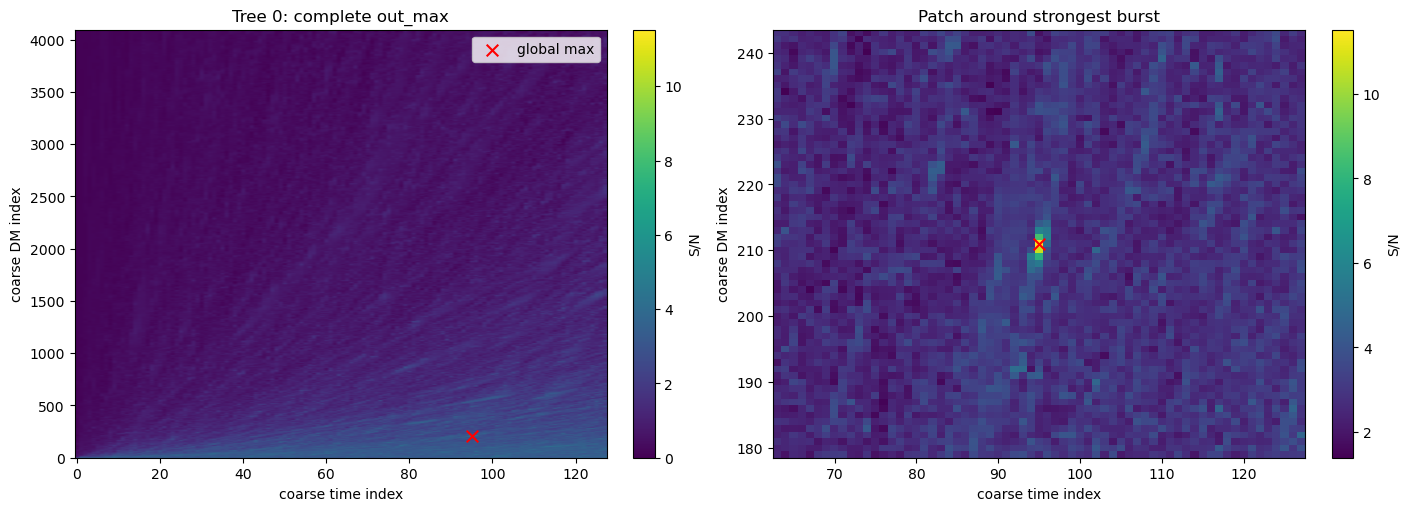

In [3]:
# Make the selected device current for all later CuPy work.
cp.cuda.Device(GPU_DEVICE).use()

# The two selected maps cross the PCIe boundary exactly once.
with cp.cuda.Device(GPU_DEVICE):
    snr_gpu = cp.asarray(snr_cpu)
    argmax_gpu = cp.asarray(argmax_cpu)

    global_flat = int(cp.argmax(snr_gpu).item())
    global_idm, global_itime = divmod(global_flat, ntime)
    global_snr = float(snr_gpu[global_idm, global_itime].item())
    input_above_threshold = int(cp.count_nonzero(snr_gpu > SNR_THRESHOLD).item())

patch_dm0 = max(0, global_idm - PATCH_HALF_SIZE[0])
patch_dm1 = min(ndm, global_idm + PATCH_HALF_SIZE[0] + 1)
patch_t0 = max(0, global_itime - PATCH_HALF_SIZE[1])
patch_t1 = min(ntime, global_itime + PATCH_HALF_SIZE[1] + 1)

print(f"global maximum: S/N={global_snr:.3f} at (idm, itime)=({global_idm}, {global_itime})")
print(f"pixels strictly above {SNR_THRESHOLD:g}: {input_above_threshold}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
im = axes[0].imshow(snr_cpu, origin="lower", aspect="auto", cmap="viridis")
axes[0].scatter(global_itime, global_idm, marker="x", color="red", s=70, label="global max")
axes[0].set(title=f"Tree {TREE_INDEX}: complete out_max", xlabel="coarse time index", ylabel="coarse DM index")
axes[0].legend()
fig.colorbar(im, ax=axes[0], label="S/N")

patch = snr_cpu[patch_dm0:patch_dm1, patch_t0:patch_t1]
im = axes[1].imshow(
    patch, origin="lower", aspect="auto", cmap="viridis",
    extent=(patch_t0 - 0.5, patch_t1 - 0.5, patch_dm0 - 0.5, patch_dm1 - 0.5),
)
axes[1].scatter(global_itime, global_idm, marker="x", color="red", s=70)
axes[1].set(title="Patch around strongest burst", xlabel="coarse time index", ylabel="coarse DM index")
fig.colorbar(im, ax=axes[1], label="S/N")
plt.show()

## 2. Common GPU candidate representation and PIRATE decoding

Every selector returns four one-dimensional, descending-S/N CuPy
arrays: `idm`, `itime`, `snr`, and `argmax_token`. Coordinates always
refer to the original saved map. Only these survivors are copied to the
host and decoded with PIRATE's existing `decode_argmax_batch()` and
`decode_argmax2_batch()` methods; the argmax token format is not
reimplemented for scientific quantities.

`time_from_acquisition_start_s` assumes chunk indices are zero-based,
contiguous, and every chunk has the saved `nt_in`. The decoder's
timestamp itself is referenced to the bottom of the observing band.

In [5]:
def _sorted_candidates(idm, itime, values, token_map=argmax_gpu):
    idm = idm.astype(cp.int64, copy=False)
    itime = itime.astype(cp.int64, copy=False)
    values = values.astype(snr_gpu.dtype, copy=False)
    order = cp.argsort(values)[::-1]
    idm, itime, values = idm[order], itime[order], values[order]
    return {
        "idm": idm,
        "itime": itime,
        "snr": values,
        "argmax_token": token_map[idm, itime],
    }


def candidates_from_mask(mask):
    idm, itime = cp.nonzero(mask)
    return _sorted_candidates(idm, itime, snr_gpu[idm, itime])


def candidate_count(candidates):
    return int(candidates["snr"].size)


def decode_candidates(candidates, method):
    # Copy and decode only a compact candidate list.
    n = candidate_count(candidates)
    columns = [
        "method", "rank", "tree", "idm", "itime", "snr", "argmax_token",
        "dm_pc_cm-3", "time_in_chunk_s", "time_from_acquisition_start_s",
        "width_ms", "freq_lo_mhz", "freq_hi_mhz", "profile",
    ]
    if n == 0:
        return Table(columns=columns)

    idm = cp.asnumpy(candidates["idm"])
    itime = cp.asnumpy(candidates["itime"])
    snr = cp.asnumpy(candidates["snr"])
    tokens = np.ascontiguousarray(cp.asnumpy(candidates["argmax_token"]), dtype=np.uint32)
    itrees = np.full(n, TREE_INDEX, dtype=np.int64)

    fmin, fmax, tlo, thi, profile = plan.decode_argmax_batch(
        tokens, itrees, np.ascontiguousarray(idm), np.ascontiguousarray(itime)
    )
    freq_lo, freq_hi, dm, timestamp_samp, width_samp = plan.decode_argmax2_batch(
        itrees, fmin, fmax, tlo, thi, profile
    )
    time_in_chunk_s = np.asarray(timestamp_samp) * sample_time_s
    time_from_start_s = int(source["time_chunk_index"]) * chunk_duration_s + time_in_chunk_s

    return Table(
        {
            "method": method,
            "rank": np.arange(1, n + 1),
            "tree": TREE_INDEX,
            "idm": idm,
            "itime": itime,
            "snr": snr,
            "argmax_token": tokens,
            "dm_pc_cm-3": np.asarray(dm),
            "time_in_chunk_s": time_in_chunk_s,
            "time_from_acquisition_start_s": time_from_start_s,
            "width_ms": np.asarray(width_samp) * time_sample_ms,
            "freq_lo_mhz": np.asarray(freq_lo),
            "freq_hi_mhz": np.asarray(freq_hi),
            "profile": np.asarray(profile),
        },
        columns=columns,
    )


def edge_cval():
    return float("inf") if EDGE_POLICY == "exclude" else float("-inf")


def reduction_factor(nselected):
    return np.inf if nselected == 0 else input_above_threshold / nselected


def _candidate_xy(candidates):
    # Compact survivor coordinates only, for Matplotlib.
    return cp.asnumpy(candidates["itime"]), cp.asnumpy(candidates["idm"])


def plot_candidate_overlay(candidates, title):
    x, y = _candidate_xy(candidates)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    im = axes[0].imshow(snr_cpu, origin="lower", aspect="auto", cmap="viridis")
    axes[0].scatter(x, y, facecolors="none", edgecolors="red", s=45, label="selected")
    axes[0].set(title=f"{title}: full map", xlabel="coarse time index", ylabel="coarse DM index")
    axes[0].legend(loc="upper right")
    fig.colorbar(im, ax=axes[0], label="S/N")

    in_patch = (x >= patch_t0) & (x < patch_t1) & (y >= patch_dm0) & (y < patch_dm1)
    im = axes[1].imshow(
        snr_cpu[patch_dm0:patch_dm1, patch_t0:patch_t1],
        origin="lower", aspect="auto", cmap="viridis",
        extent=(patch_t0 - 0.5, patch_t1 - 0.5, patch_dm0 - 0.5, patch_dm1 - 0.5),
    )
    axes[1].scatter(x[in_patch], y[in_patch], facecolors="none", edgecolors="red", s=55)
    axes[1].set(title=f"{title}: strongest-burst patch", xlabel="coarse time index", ylabel="coarse DM index")
    fig.colorbar(im, ax=axes[1], label="S/N")
    plt.show()

## 3. Adaptive sub-band bowtie filter

`out_max` is already maximized over sub-band, width, and fine trial. The
central pixel's `out_argmax` identifies which sub-band won there; this does
not create separate per-sub-band S/N maps. Neighbouring footprint values
still come from the common `out_max` map and may themselves have different
winning sub-bands.

This keeps the established exploratory geometry unchanged. For DM offsets
`[-ADAPTIVE_DM_REACH, +ADAPTIVE_DM_REACH]`, dispersion delays from the
full-band low edge to each winning sub-band edge set the two sides of an
inclusive bowtie. Positive offsets extend the upper side by
`ADAPTIVE_WAIST_BINS`; negative offsets extend the lower side; the zero row
spans `±ADAPTIVE_WAIST_BINS`.

One original boolean footprint is constructed for every distinct frequency
band. Because the continuous geometry is discretized onto DM/time bins,
different bands can produce exactly equal masks. Exact duplicates are
identified only when both shape and every boolean cell agree; equal shape
alone is insufficient. The optimized path maps
`pixel_band_map -> band_to_unique -> pixel_unique_bowtie_map` and performs
one complete `maximum_filter` pass per exactly unique footprint. Values
filtered for a footprint are retained only at central pixels assigned to
that footprint. Equal-valued S/N ties are retained.

In [6]:
from cupyx.scipy.ndimage import maximum_filter as gpu_maximum_filter
from peakfinder_tests.peakfinders import (
    K_DM,
    deduplicate_bowtie_bank_gpu,
    make_multiplet_band_lookup,
    make_pixel_band_map_gpu,
    make_subband_bowtie_gpu,
)


def build_bowtie_bank_gpu(band_lo, band_hi):
    return [
        make_subband_bowtie_gpu(
            ADAPTIVE_DM_REACH, dm_bin, time_bin_s, float(lo), float(hi),
            reference_freq_mhz, ADAPTIVE_WAIST_BINS,
        )
        for lo, hi in zip(band_lo, band_hi)
    ]


def _maximum_filter_cval(edge_policy):
    if edge_policy == "exclude":
        return float("inf")
    if edge_policy == "include":
        return float("-inf")
    raise ValueError("EDGE_POLICY must be exclude or include")


def _adaptive_filter_gpu(snr_map, pixel_footprint_map, footprints):
    # Keep the notebook diagnostic API: selected maximum map, candidate mask,
    # and compact candidate arrays. This is the same per-pixel footprint
    # selection used by the current Bowtie-banks implementation.
    filter_map = snr_map.astype(cp.float32) if snr_map.dtype == cp.float16 else snr_map
    selected_max = cp.empty_like(filter_map)
    cval = _maximum_filter_cval(EDGE_POLICY)
    for footprint_index, footprint in enumerate(footprints):
        filtered = gpu_maximum_filter(
            filter_map, footprint=footprint, mode="constant", cval=cval
        )
        centres = pixel_footprint_map == footprint_index
        selected_max[centres] = filtered[centres]
    candidate_mask = (snr_map > SNR_THRESHOLD) & (snr_map == selected_max)
    return selected_max, candidate_mask, candidates_from_mask(candidate_mask)


def adaptive_filter_full_bank_gpu(snr_map, band_map, footprints):
    return _adaptive_filter_gpu(snr_map, band_map, footprints)


def adaptive_filter_unique_bank_gpu(snr_map, pixel_unique_bowtie_map, unique_footprints):
    return _adaptive_filter_gpu(snr_map, pixel_unique_bowtie_map, unique_footprints)


In [ ]:
with cp.cuda.Device(GPU_DEVICE):
    m_to_band_cpu, band_pairs, band_lo, band_hi = make_multiplet_band_lookup(plan, TREE_INDEX)
    m_to_band_gpu = cp.asarray(m_to_band_cpu)
    bowties_gpu = build_bowtie_bank_gpu(band_lo, band_hi)
    band_map_gpu = make_pixel_band_map_gpu(argmax_gpu, m_to_band_gpu)

    unique_bowties_gpu, band_to_unique_cpu, unique_to_bands = (
        deduplicate_bowtie_bank_gpu(bowties_gpu)
    )
    band_to_unique_gpu = cp.asarray(band_to_unique_cpu)
    pixel_unique_bowtie_map_gpu = band_to_unique_gpu[band_map_gpu]

    original_adaptive_max_gpu, original_candidate_mask_gpu, original_adaptive_candidates = (
        adaptive_filter_full_bank_gpu(snr_gpu, band_map_gpu, bowties_gpu)
    )
    adaptive_max_gpu, adaptive_candidate_mask_gpu, adaptive_candidates = (
        adaptive_filter_unique_bank_gpu(
            snr_gpu, pixel_unique_bowtie_map_gpu, unique_bowties_gpu
        )
    )

footprint_cpu = [np.ascontiguousarray(cp.asnumpy(fp), dtype=np.bool_) for fp in bowties_gpu]
diagnostic_rows = []
for band, (pair, lo, hi, footprint) in enumerate(
    zip(band_pairs, band_lo, band_hi, footprint_cpu)
):
    diagnostic_rows.append(
        {
            "original_band": band,
            "(fmin_code, fmax_code)": tuple(int(value) for value in pair),
            "freq_lo_mhz": float(lo),
            "freq_hi_mhz": float(hi),
            "footprint_shape": tuple(footprint.shape),
            "true_cells": int(np.count_nonzero(footprint)),
            "unique_footprint": int(band_to_unique_cpu[band]),
        }
    )

print("Original frequency-band bowties:")
display(Table(diagnostic_rows))

distinct_shapes = sorted({tuple(footprint.shape) for footprint in footprint_cpu})
nmultiplets = len(m_to_band_cpu)
ngenerated = len(bowties_gpu)
nunique = len(unique_bowties_gpu)
nredundant = ngenerated - nunique
bank_reduction = ngenerated / nunique if nunique else np.inf
print("Bowtie-bank summary:")
print(f"  multiplets:                    {nmultiplets}")
print(f"  distinct frequency-band pairs: {len(band_pairs)}")
print(f"  generated bowties:             {ngenerated}")
print(f"  distinct bowtie shapes:        {len(distinct_shapes)}")
print(f"  exactly unique bowties:        {nunique}")
print(f"  redundant bowties:             {nredundant}")
print(f"  full/unique bank reduction:     {bank_reduction:.3g}x")

duplicate_groups = [
    (unique_index, bands)
    for unique_index, bands in enumerate(unique_to_bands)
    if len(bands) > 1
]
if duplicate_groups:
    print("Exact duplicate groups:")
    for unique_index, bands in duplicate_groups:
        print(f"  Unique bowtie {unique_index} is shared by original bands: {bands}")
else:
    print("Exact duplicate groups: none")

shape_to_bands = {}
for band, footprint in enumerate(footprint_cpu):
    shape_to_bands.setdefault(tuple(footprint.shape), []).append(band)
same_shape_different = []
for shape, bands in shape_to_bands.items():
    unique_indices = sorted({int(band_to_unique_cpu[band]) for band in bands})
    if len(bands) > 1 and len(unique_indices) > 1:
        same_shape_different.append((shape, bands, unique_indices))
if same_shape_different:
    print("Same shape but different boolean contents (kept separate):")
    for shape, bands, unique_indices in same_shape_different:
        print(f"  shape={shape}: bands={bands}, exact unique footprints={unique_indices}")
else:
    print("Same shape but different boolean contents: none")

with cp.cuda.Device(GPU_DEVICE):
    maps_equal = bool(cp.array_equal(original_adaptive_max_gpu, adaptive_max_gpu).item())
    differing_map_pixels_gpu = original_adaptive_max_gpu != adaptive_max_gpu
    differing_pixels = int(cp.count_nonzero(differing_map_pixels_gpu).item())
    max_abs_difference = (
        float(cp.max(cp.abs(
            original_adaptive_max_gpu[differing_map_pixels_gpu]
            - adaptive_max_gpu[differing_map_pixels_gpu]
        )).item())
        if differing_pixels
        else 0.0
    )
    masks_equal = bool(
        cp.array_equal(original_candidate_mask_gpu, adaptive_candidate_mask_gpu).item()
    )
    candidate_fields = ("idm", "itime", "snr", "argmax_token")
    ordered_candidates_equal = all(
        bool(cp.array_equal(
            original_adaptive_candidates[field], adaptive_candidates[field]
        ).item())
        for field in candidate_fields
    )

print("Correctness comparison (original full bank vs exact-deduplicated bank):")
print(f"  adaptive maximum maps exactly equal: {maps_equal}")
print(f"  maximum absolute difference:         {max_abs_difference}")
print(f"  differing pixels:                    {differing_pixels}")
print(f"  candidate masks exactly equal:       {masks_equal}")
print(f"  ordered candidate lists identical:   {ordered_candidates_equal}")
assert maps_equal, "Deduplicated adaptive maximum map differs from the full-bank reference"
assert max_abs_difference == 0.0
assert differing_pixels == 0
assert masks_equal, "Deduplicated candidate mask differs from the full-bank reference"
assert ordered_candidates_equal, "Deduplicated ordered candidates differ from the reference"

passes_eliminated = ngenerated - nunique
eliminated_percent = 100.0 * passes_eliminated / ngenerated if ngenerated else 0.0
print("Filter-pass reduction:")
print(f"  original passes:     {ngenerated}")
print(f"  deduplicated passes: {nunique}")
print(f"  eliminated:          {passes_eliminated} ({eliminated_percent:.1f}%)")

### Unique adaptive-bowtie footprints

Every panel below is one non-redundant logical mask. Pixel coordinates are
displayed as centered time-bin and DM-bin offsets; the thin reference lines
mark zero time and zero DM. Original band identities and frequency ranges
remain available even when several bands share one exact footprint.

In [ ]:
MAX_BOWTIE_PANELS_PER_FIGURE = 12


def _centered_ticks(radius, maximum_ticks=7):
    step = max(1, int(np.ceil((2 * radius + 1) / maximum_ticks)))
    ticks = np.arange(-radius, radius + 1, step, dtype=int)
    if 0 not in ticks:
        ticks = np.sort(np.append(ticks, 0))
    return ticks


def plot_unique_bowtie_bank(unique_footprints, unique_to_bands, band_lo, band_hi,
                            max_panels_per_figure=12):
    if max_panels_per_figure < 1:
        raise ValueError("max_panels_per_figure must be positive")
    unique_cpu = [np.ascontiguousarray(cp.asnumpy(fp), dtype=np.bool_) for fp in unique_footprints]
    for page_start in range(0, len(unique_cpu), max_panels_per_figure):
        page_stop = min(page_start + max_panels_per_figure, len(unique_cpu))
        page_indices = list(range(page_start, page_stop))
        ncols = min(3, len(page_indices))
        nrows = int(np.ceil(len(page_indices) / ncols))
        fig, axes = plt.subplots(
            nrows, ncols, figsize=(5.2 * ncols, 4.3 * nrows),
            constrained_layout=True, squeeze=False,
        )
        for ax, unique_index in zip(axes.flat, page_indices):
            footprint = unique_cpu[unique_index]
            dm_radius = (footprint.shape[0] - 1) // 2
            time_radius = (footprint.shape[1] - 1) // 2
            extent = (
                -time_radius - 0.5, time_radius + 0.5,
                -dm_radius - 0.5, dm_radius + 0.5,
            )
            ax.imshow(
                footprint, origin="lower", interpolation="nearest",
                cmap="binary", vmin=0, vmax=1, extent=extent, aspect="auto",
            )
            ax.axvline(0, color="tab:red", linewidth=0.7, alpha=0.8)
            ax.axhline(0, color="tab:red", linewidth=0.7, alpha=0.8)
            ax.set_xticks(_centered_ticks(time_radius))
            ax.set_yticks(_centered_ticks(dm_radius))
            ax.set_xlabel("time-bin offset")
            ax.set_ylabel("DM-bin offset")
            bands = unique_to_bands[unique_index]
            ranges = ", ".join(f"{band_lo[b]:.1f}-{band_hi[b]:.1f}" for b in bands)
            ax.set_title(
                f"unique {unique_index}: shape={footprint.shape}, true={np.count_nonzero(footprint)}\n"
                f"bands={bands}; MHz={ranges}",
                fontsize=9,
            )
        for ax in axes.flat[len(page_indices):]:
            ax.set_visible(False)
        fig.suptitle(
            f"Exactly unique adaptive bowties ({page_start + 1}-{page_stop} of {len(unique_cpu)})",
            fontsize=13,
        )
        plt.show()


plot_unique_bowtie_bank(
    unique_bowties_gpu, unique_to_bands, band_lo, band_hi,
    max_panels_per_figure=MAX_BOWTIE_PANELS_PER_FIGURE,
)

## 4. Geometry derived from the bowtie bank

The exactly unique adaptive masks are embedded on one centered
`(delta_DM, delta_time)` grid. Their logical OR defines the union.
The convex-hull footprint is obtained from the continuous convex
hull of the active union-pixel **centres**, then discretized by
including every integer pixel centre lying inside or exactly on the
hull boundary. Cross products use integer arithmetic, so boundary
inclusion needs no floating-point tolerance or manual dilation.

The bounding rectangle is the all-True mask over the union's minimal
centered extent. Thus all scales come only from the existing PIRATE
bowtie geometry, with expected containment
`B_band ⊆ B_union ⊆ B_hull ⊆ B_rectangle`.

unique_footprint,original_bands,shape,true_cells
0,[0],"(17, 19)",41
1,[1],"(17, 19)",61
2,[2],"(17, 19)",101
3,[3],"(17, 17)",37
4,[4],"(17, 15)",39
5,[5],"(17, 15)",51


Derived geometry:
  original bowties:                         6
  exactly unique bowties:                   6
  union:       shape=(17, 19), true=101
  convex hull: shape=(17, 19), true=155
  rectangle:   shape=(17, 19), true=323
  union occupancy within hull:              65.161%
  union occupancy within rectangle:         31.269%
  hull occupancy within rectangle:          47.988%
  containment band <= union <= hull <= rectangle: True


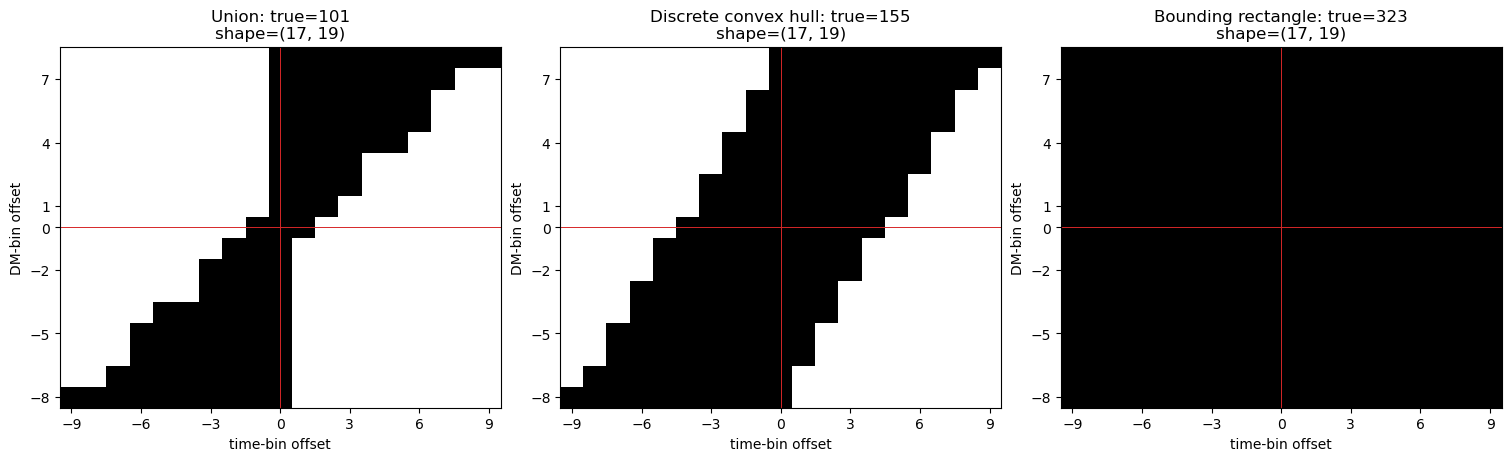

In [8]:
from peakfinder_tests.peakfinders import (
    centered_active_offsets_cpu,
    make_bowtie_bounding_rectangle_gpu,
    make_convex_hull_bowtie_gpu,
    make_union_bowtie_gpu,
)


with cp.cuda.Device(GPU_DEVICE):
    union_bowtie_gpu = make_union_bowtie_gpu(unique_bowties_gpu)
    convex_hull_bowtie_gpu, convex_hull_vertices = make_convex_hull_bowtie_gpu(union_bowtie_gpu)
    bowtie_rectangle_gpu = make_bowtie_bounding_rectangle_gpu(union_bowtie_gpu)

original_offset_sets = [centered_active_offsets_cpu(fp) for fp in bowties_gpu]
unique_offset_sets = [centered_active_offsets_cpu(fp) for fp in unique_bowties_gpu]
union_offsets = centered_active_offsets_cpu(union_bowtie_gpu)
hull_offsets = centered_active_offsets_cpu(convex_hull_bowtie_gpu)
rectangle_offsets = centered_active_offsets_cpu(bowtie_rectangle_gpu)
assert all(offsets <= union_offsets for offsets in original_offset_sets)
assert all(offsets <= union_offsets for offsets in unique_offset_sets)
assert union_offsets <= hull_offsets <= rectangle_offsets

unique_geometry_rows = [
    {
        "unique_footprint": index,
        "original_bands": unique_to_bands[index],
        "shape": tuple(footprint.shape),
        "true_cells": int(cp.count_nonzero(footprint).item()),
    }
    for index, footprint in enumerate(unique_bowties_gpu)
]
display(Table(unique_geometry_rows))

union_true = int(cp.count_nonzero(union_bowtie_gpu).item())
hull_true = int(cp.count_nonzero(convex_hull_bowtie_gpu).item())
rectangle_true = int(cp.count_nonzero(bowtie_rectangle_gpu).item())
print("Derived geometry:")
print(f"  original bowties:                         {len(bowties_gpu)}")
print(f"  exactly unique bowties:                   {len(unique_bowties_gpu)}")
print(f"  union:       shape={union_bowtie_gpu.shape}, true={union_true}")
print(f"  convex hull: shape={convex_hull_bowtie_gpu.shape}, true={hull_true}")
print(f"  rectangle:   shape={bowtie_rectangle_gpu.shape}, true={rectangle_true}")
print(f"  union occupancy within hull:              {union_true / hull_true:.3%}")
print(f"  union occupancy within rectangle:         {union_true / rectangle_true:.3%}")
print(f"  hull occupancy within rectangle:          {hull_true / rectangle_true:.3%}")
print(f"  containment band <= union <= hull <= rectangle: True")

geometry_cpu = [
    cp.asnumpy(union_bowtie_gpu),
    cp.asnumpy(convex_hull_bowtie_gpu),
    cp.asnumpy(bowtie_rectangle_gpu),
]
geometry_titles = [
    f"Union: true={union_true}",
    f"Discrete convex hull: true={hull_true}",
    f"Bounding rectangle: true={rectangle_true}",
]
dm_radius = union_bowtie_gpu.shape[0] // 2
time_radius = union_bowtie_gpu.shape[1] // 2
extent = (-time_radius-0.5, time_radius+0.5, -dm_radius-0.5, dm_radius+0.5)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
for ax, footprint, title in zip(axes, geometry_cpu, geometry_titles):
    ax.imshow(
        footprint, origin="lower", interpolation="nearest", cmap="binary",
        vmin=0, vmax=1, extent=extent, aspect="auto",
    )
    ax.axvline(0, color="tab:red", linewidth=0.7)
    ax.axhline(0, color="tab:red", linewidth=0.7)
    ax.set_xticks(_centered_ticks(time_radius))
    ax.set_yticks(_centered_ticks(dm_radius))
    ax.set(title=f"{title}\nshape={footprint.shape}", xlabel="time-bin offset", ylabel="DM-bin offset")
plt.show()

## 5. Apply the five algorithms

Adaptive, union, convex hull, and rectangle all apply
`maximum_filter` to the complete S/N map before the common strict
significance cut. Connected components instead constructs `S > T`,
labels it with 8-connectivity on the GPU, and selects one maximum
original-S/N pixel per component. Equal S/N values inside a component
are resolved deterministically by the smallest row-major pixel index.
This remains a two-dimensional, per-tree diagnostic—not cross-tree
grouping.

In [ ]:
from cupyx.scipy.ndimage import label as gpu_connected_component_label


def fixed_footprint_candidates_gpu(snr_map, footprint):
    filter_map = snr_map.astype(cp.float32) if snr_map.dtype == cp.float16 else snr_map
    maximum_map = gpu_maximum_filter(
        filter_map, footprint=footprint, mode="constant",
        cval=_maximum_filter_cval(EDGE_POLICY),
    )
    candidate_mask = (snr_map > SNR_THRESHOLD) & (snr_map == maximum_map)
    return maximum_map, candidate_mask, candidates_from_mask(candidate_mask)


CONNECTED_COMPONENT_STRUCTURE_GPU = cp.ones((3, 3), dtype=cp.int8)


def connected_component_maxima_gpu(snr_map, threshold, structure):
    threshold_mask = snr_map > threshold
    labels, ncomponents = gpu_connected_component_label(
        threshold_mask, structure=structure
    )
    flat_indices = cp.flatnonzero(threshold_mask)
    if flat_indices.size == 0:
        empty = cp.empty(0, dtype=cp.int64)
        candidates = _sorted_candidates(empty, empty, cp.empty(0, dtype=snr_map.dtype))
        return threshold_mask, labels, int(ncomponents), candidates

    values = snr_map.ravel()[flat_indices]
    component_ids = labels.ravel()[flat_indices]
    # Primary key: component. Secondary: decreasing S/N. Tertiary:
    # increasing flat index for deterministic equal-S/N ties.
    order = cp.lexsort(cp.stack((flat_indices, -values, component_ids)))
    sorted_components = component_ids[order]
    sorted_flat = flat_indices[order]
    first_in_component = cp.empty(sorted_components.size, dtype=cp.bool_)
    first_in_component[0] = True
    first_in_component[1:] = sorted_components[1:] != sorted_components[:-1]
    winner_flat = sorted_flat[first_in_component]
    winner_idm = winner_flat // snr_map.shape[1]
    winner_itime = winner_flat % snr_map.shape[1]
    candidates = _sorted_candidates(
        winner_idm, winner_itime, snr_map[winner_idm, winner_itime]
    )
    return threshold_mask, labels, int(ncomponents), candidates


with cp.cuda.Device(GPU_DEVICE):
    union_max_gpu, union_mask_gpu, union_candidates = fixed_footprint_candidates_gpu(
        snr_gpu, union_bowtie_gpu
    )
    hull_max_gpu, hull_mask_gpu, hull_candidates = fixed_footprint_candidates_gpu(
        snr_gpu, convex_hull_bowtie_gpu
    )
    rectangle_max_gpu, rectangle_mask_gpu, rectangle_candidates = fixed_footprint_candidates_gpu(
        snr_gpu, bowtie_rectangle_gpu
    )
    component_threshold_mask_gpu, component_labels_gpu, ncomponents, component_candidates = (
        connected_component_maxima_gpu(
            snr_gpu, SNR_THRESHOLD, CONNECTED_COMPONENT_STRUCTURE_GPU
        )
    )

if candidate_count(component_candidates) != ncomponents:
    raise AssertionError("Connected-component method did not return exactly one maximum per component")

algorithm_candidates = [
    ("Adaptive bowtie bank", adaptive_candidates),
    ("Union bowtie", union_candidates),
    ("Convex-hull bowtie", hull_candidates),
    ("Bowtie bounding rectangle", rectangle_candidates),
    ("Connected-component maximum", component_candidates),
]


def report_algorithm(name, candidates):
    nselected = candidate_count(candidates)
    print(name)
    print(f"  input map pixels:       {snr_gpu.size}")
    print(f"  pixels above threshold: {input_above_threshold}")
    print(f"  selected candidates:    {nselected}")
    print(f"  reduction factor:       {reduction_factor(nselected):.3g}")
    if nselected:
        strongest_snr = float(candidates["snr"][0].item())
        strongest_idm = int(candidates["idm"][0].item())
        strongest_itime = int(candidates["itime"][0].item())
        print(
            f"  strongest: S/N={strongest_snr:.3f}, "
            f"(idm, itime)=({strongest_idm}, {strongest_itime})"
        )
    display(decode_candidates(candidates, name).head(MAX_TABLE_ROWS))


for name, candidates in algorithm_candidates:
    report_algorithm(name, candidates)
print(f"Connected components labeled: {ncomponents}")


## 6. Systematic visual diagnostics

Every maximum-filter method below uses the same original-map color
scale and layout: original S/N, filtered maximum map, full-map
survivors, and the common strongest-burst zoom. Non-finite excluded
edge values in filtered maps are masked for display only.

Connected components has no footprint or filtered-maximum map, so its
equivalent panels show the strict threshold mask, 8-connected labels,
selected component maxima, the full overlay, and the same zoom.

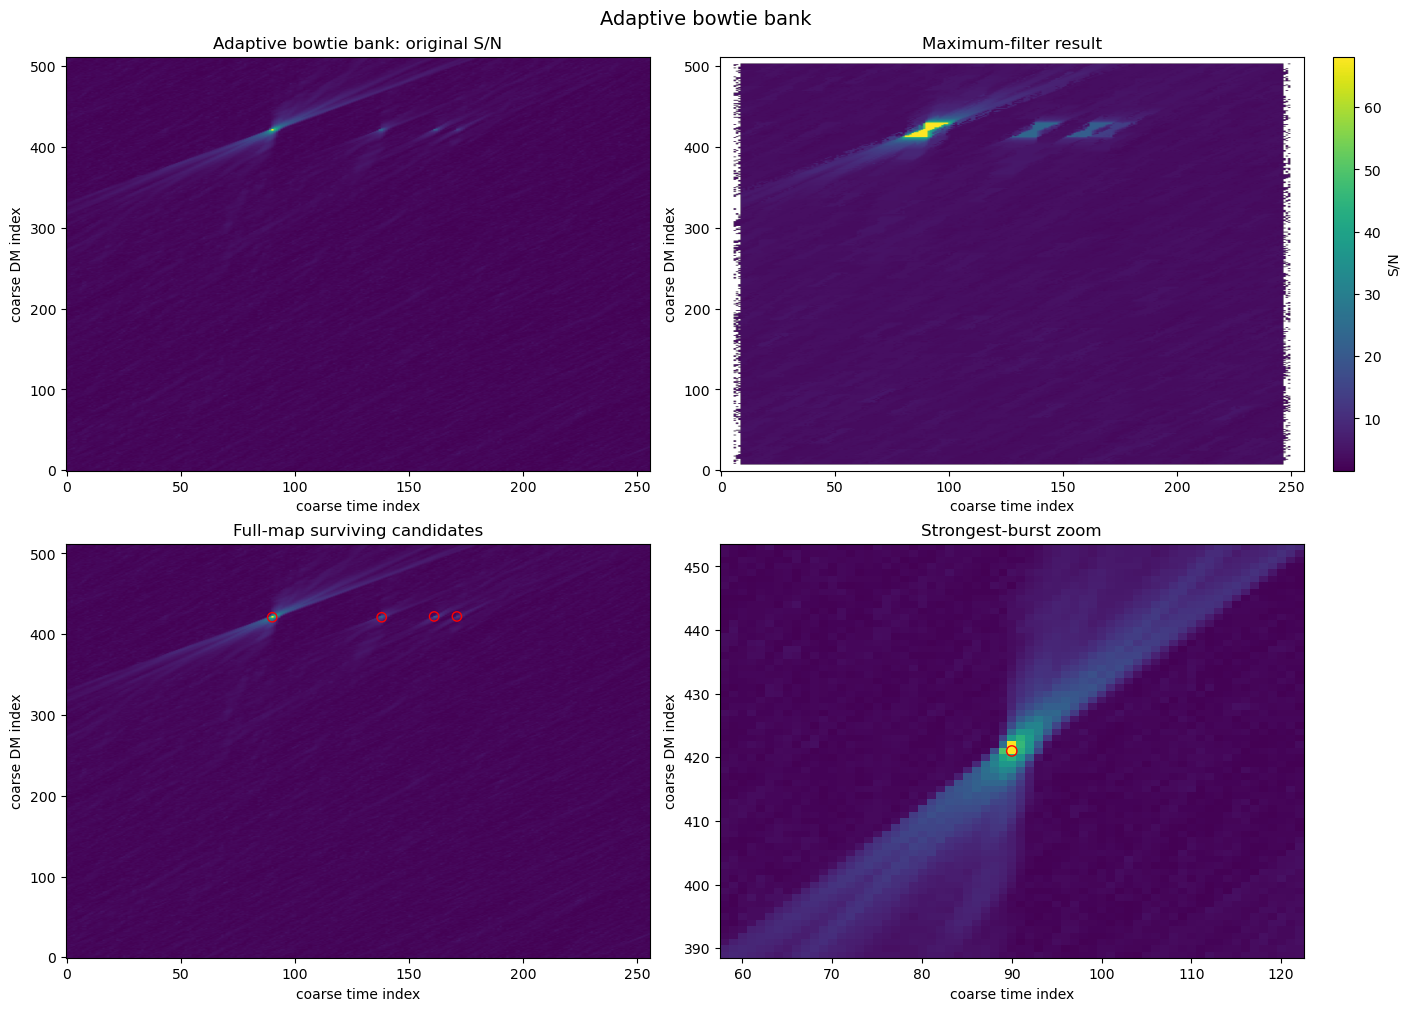

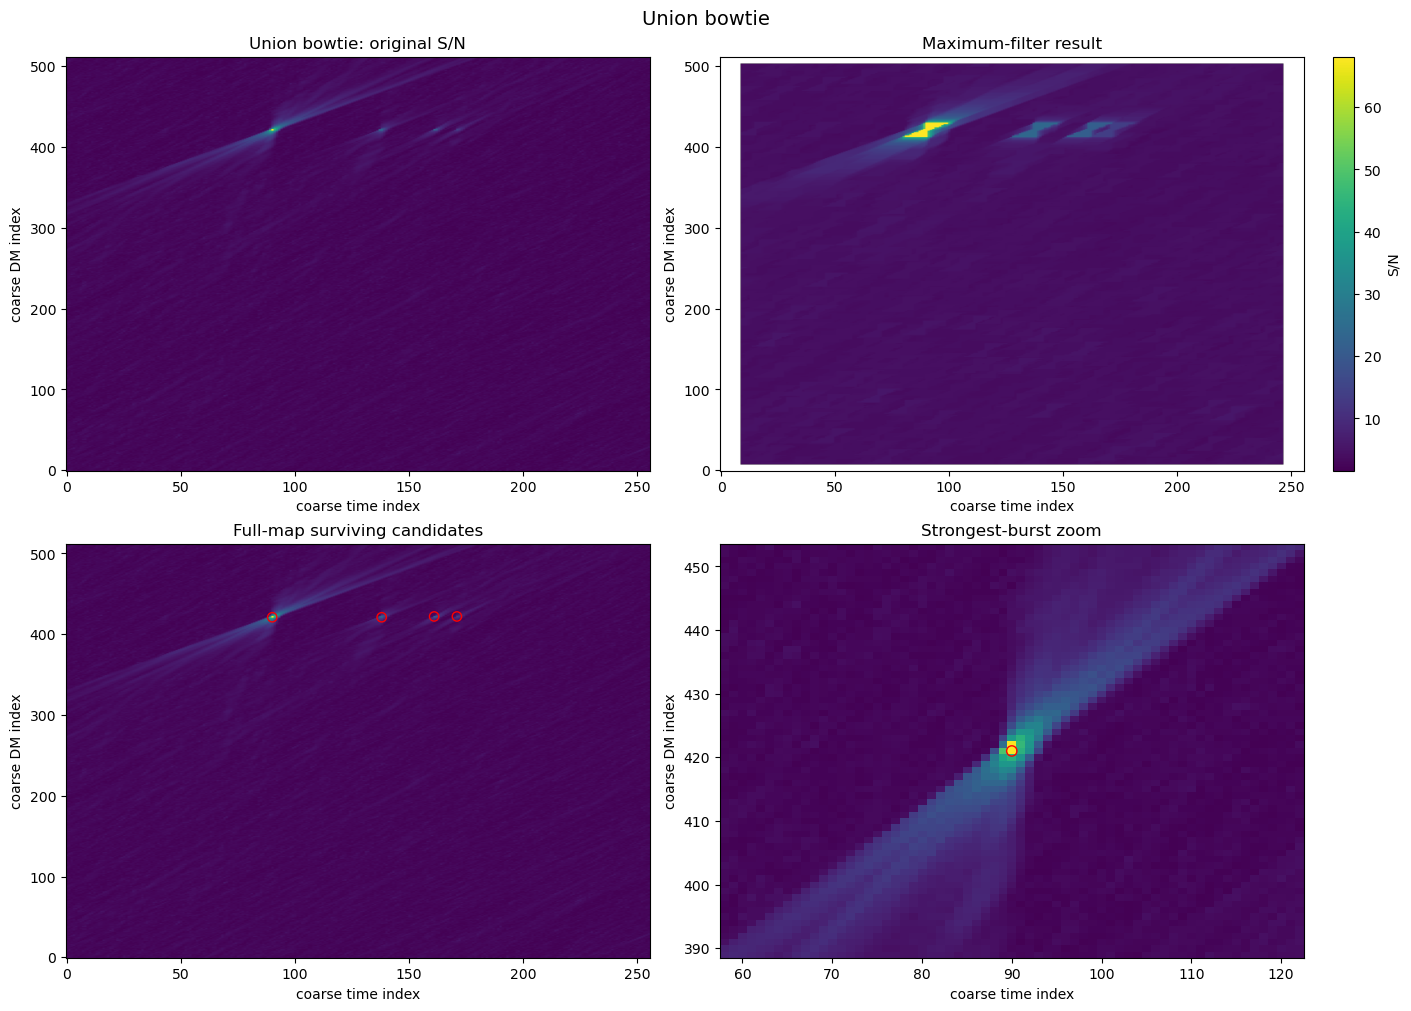

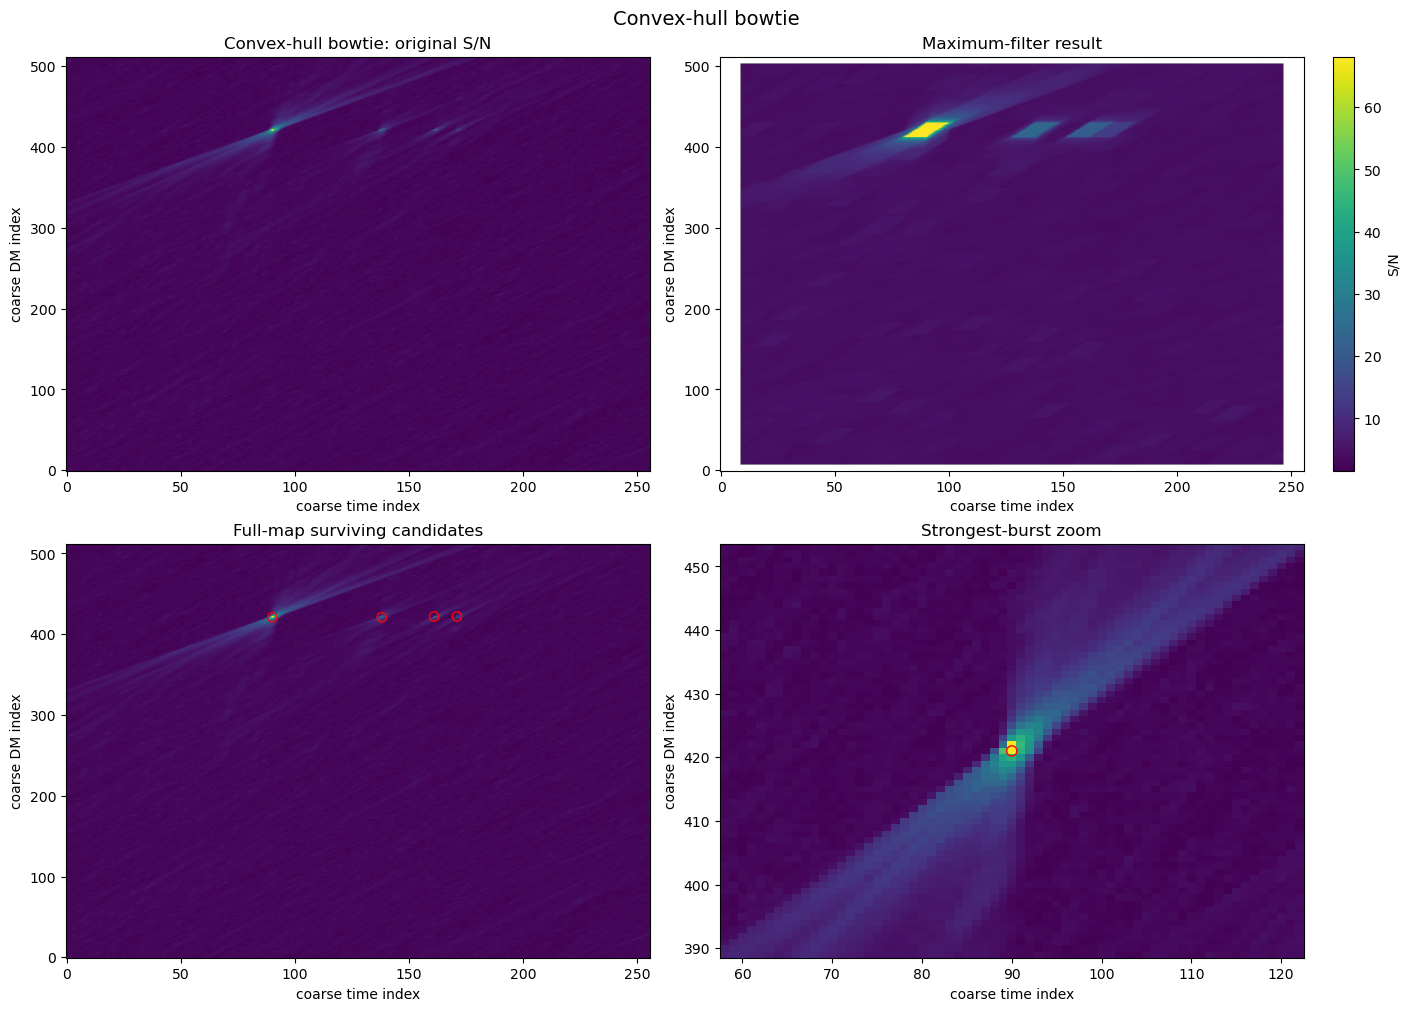

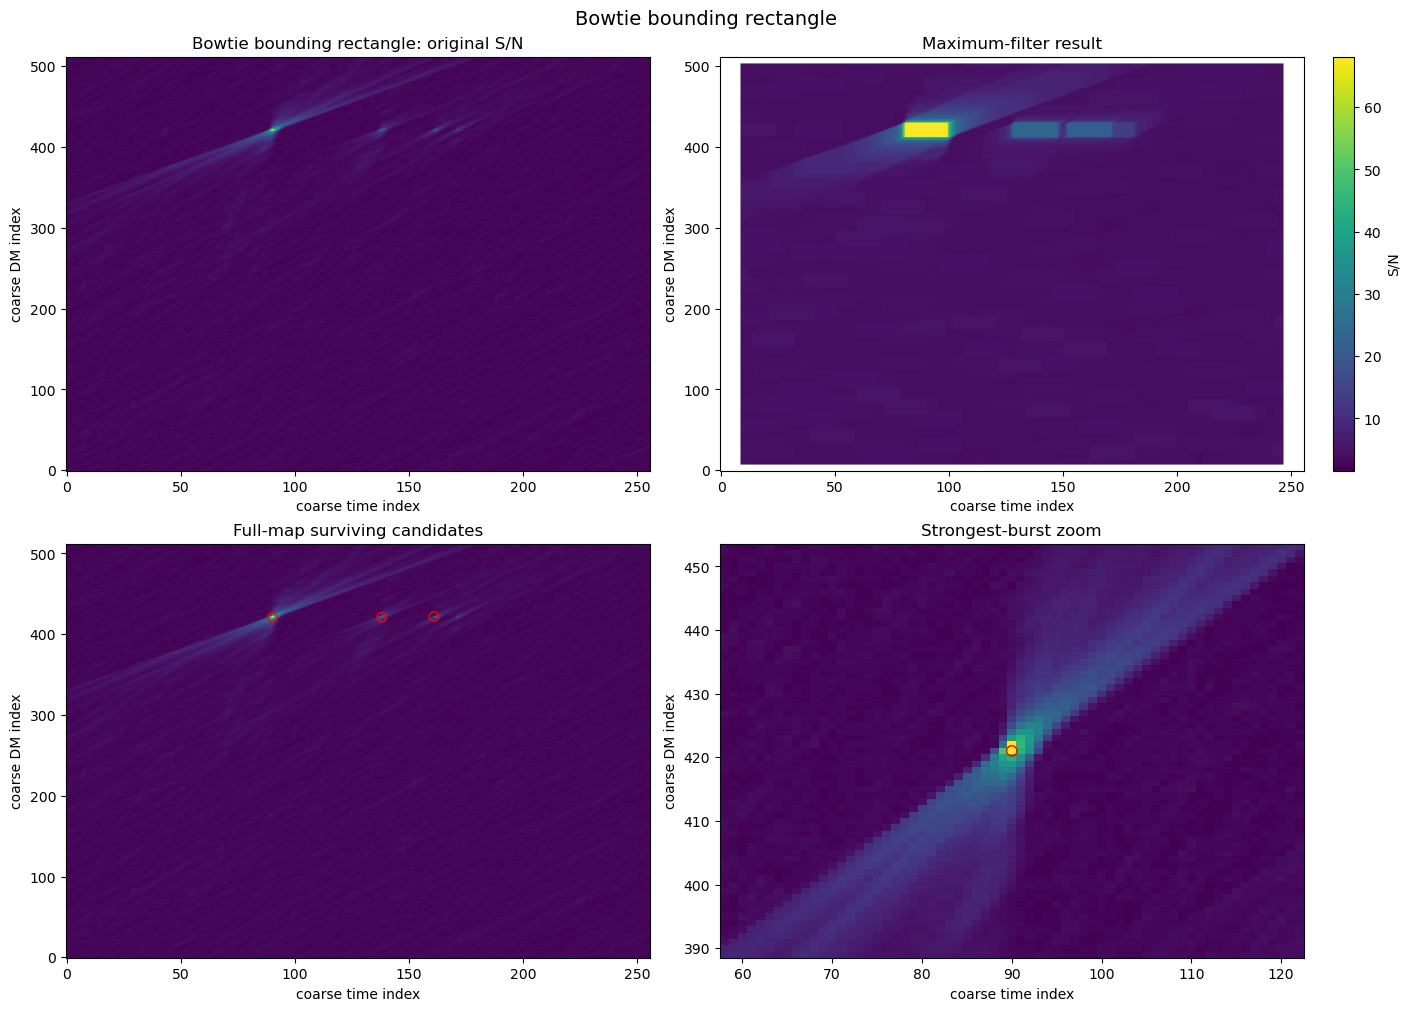

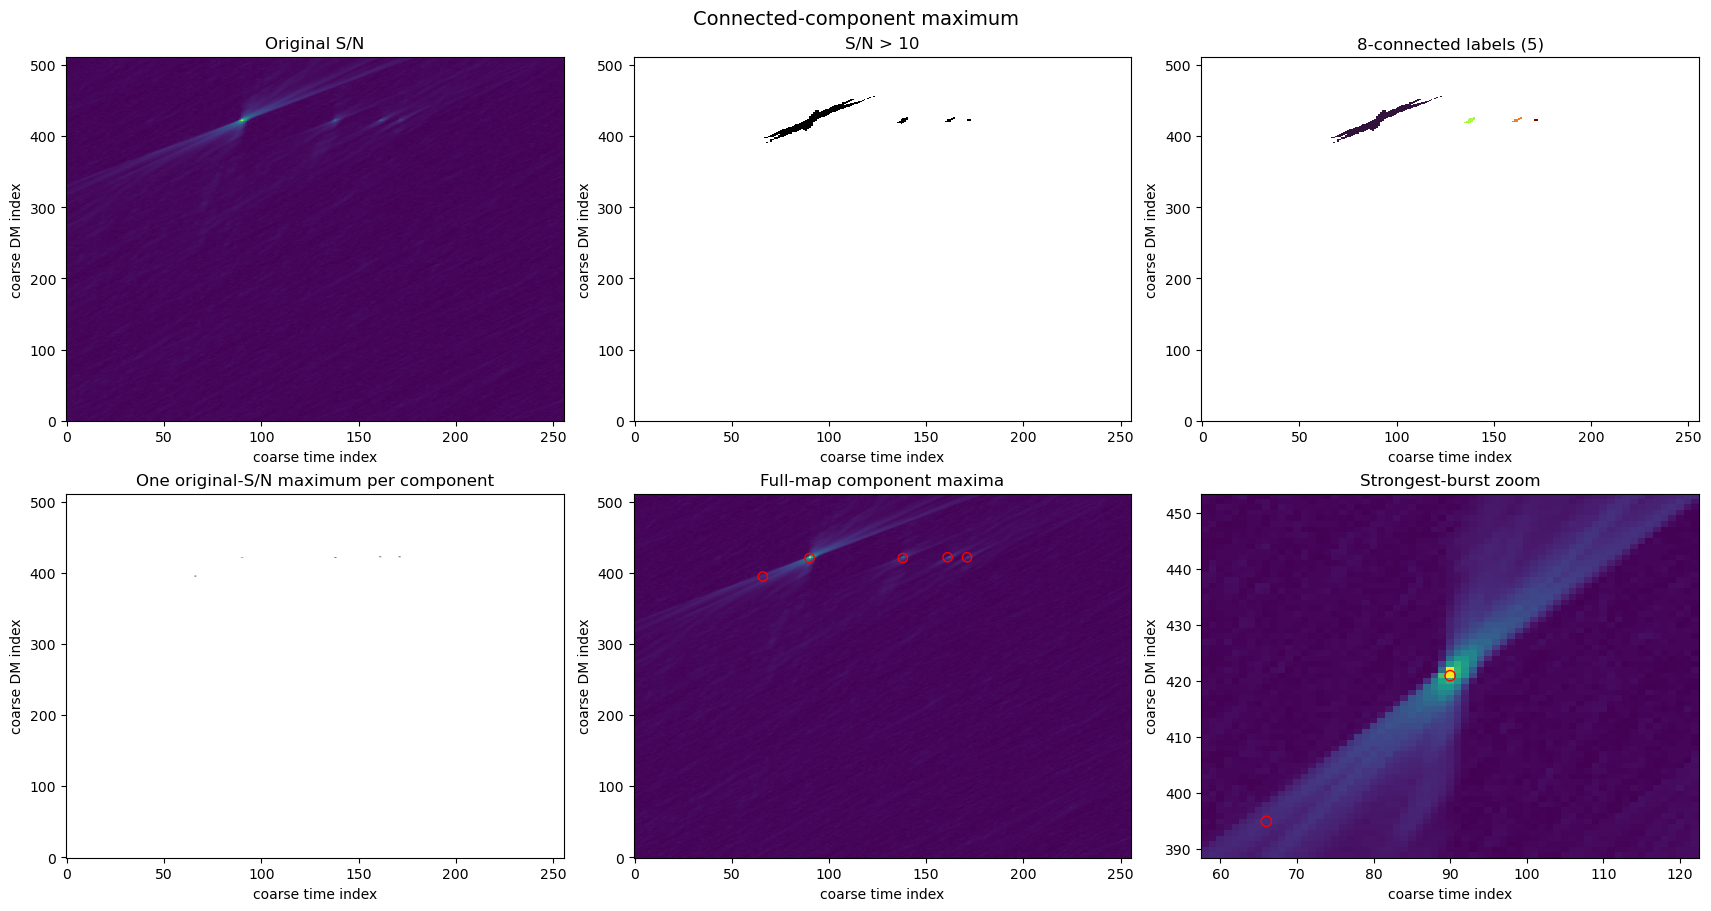

In [10]:
COMMON_VMIN = float(np.percentile(snr_cpu, 1.0))
COMMON_VMAX = global_snr


def compact_candidate_xy(candidates):
    return cp.asnumpy(candidates["itime"]), cp.asnumpy(candidates["idm"])


def plot_maximum_filter_method(name, filtered_gpu, candidates):
    filtered_cpu = cp.asnumpy(filtered_gpu)
    filtered_cpu = np.where(np.isfinite(filtered_cpu), filtered_cpu, np.nan)
    x, y = compact_candidate_xy(candidates)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
    axes[0, 0].imshow(
        snr_cpu, origin="lower", aspect="auto", cmap="viridis",
        vmin=COMMON_VMIN, vmax=COMMON_VMAX,
    )
    axes[0, 0].set(title=f"{name}: original S/N", xlabel="coarse time index", ylabel="coarse DM index")
    im = axes[0, 1].imshow(
        filtered_cpu, origin="lower", aspect="auto", cmap="viridis",
        vmin=COMMON_VMIN, vmax=COMMON_VMAX,
    )
    axes[0, 1].set(title="Maximum-filter result", xlabel="coarse time index", ylabel="coarse DM index")
    fig.colorbar(im, ax=axes[0, 1], label="S/N")
    axes[1, 0].imshow(
        snr_cpu, origin="lower", aspect="auto", cmap="viridis",
        vmin=COMMON_VMIN, vmax=COMMON_VMAX,
    )
    axes[1, 0].scatter(x, y, facecolors="none", edgecolors="red", s=45)
    axes[1, 0].set(title="Full-map surviving candidates", xlabel="coarse time index", ylabel="coarse DM index")
    inside = (x >= patch_t0) & (x < patch_t1) & (y >= patch_dm0) & (y < patch_dm1)
    axes[1, 1].imshow(
        snr_cpu[patch_dm0:patch_dm1, patch_t0:patch_t1],
        origin="lower", aspect="auto", cmap="viridis",
        vmin=COMMON_VMIN, vmax=COMMON_VMAX,
        extent=(patch_t0-0.5, patch_t1-0.5, patch_dm0-0.5, patch_dm1-0.5),
    )
    axes[1, 1].scatter(x[inside], y[inside], facecolors="none", edgecolors="red", s=55)
    axes[1, 1].set(title="Strongest-burst zoom", xlabel="coarse time index", ylabel="coarse DM index")
    fig.suptitle(name, fontsize=14)
    plt.show()


plot_maximum_filter_method("Adaptive bowtie bank", adaptive_max_gpu, adaptive_candidates)
plot_maximum_filter_method("Union bowtie", union_max_gpu, union_candidates)
plot_maximum_filter_method("Convex-hull bowtie", hull_max_gpu, hull_candidates)
plot_maximum_filter_method("Bowtie bounding rectangle", rectangle_max_gpu, rectangle_candidates)

component_threshold_cpu = cp.asnumpy(component_threshold_mask_gpu)
component_labels_cpu = cp.asnumpy(component_labels_gpu)
component_maxima_cpu = np.full(snr_cpu.shape, np.nan, dtype=np.float32)
component_idm = cp.asnumpy(component_candidates["idm"])
component_itime = cp.asnumpy(component_candidates["itime"])
component_snr = cp.asnumpy(component_candidates["snr"])
component_maxima_cpu[component_idm, component_itime] = component_snr
x, y = compact_candidate_xy(component_candidates)
fig, axes = plt.subplots(2, 3, figsize=(17, 9), constrained_layout=True)
axes[0, 0].imshow(snr_cpu, origin="lower", aspect="auto", cmap="viridis", vmin=COMMON_VMIN, vmax=COMMON_VMAX)
axes[0, 0].set(title="Original S/N", xlabel="coarse time index", ylabel="coarse DM index")
axes[0, 1].imshow(component_threshold_cpu, origin="lower", aspect="auto", cmap="binary", interpolation="nearest")
axes[0, 1].set(title=f"S/N > {SNR_THRESHOLD:g}", xlabel="coarse time index", ylabel="coarse DM index")
axes[0, 2].imshow(np.ma.masked_equal(component_labels_cpu, 0), origin="lower", aspect="auto", cmap="turbo", interpolation="nearest")
axes[0, 2].set(title=f"8-connected labels ({ncomponents})", xlabel="coarse time index", ylabel="coarse DM index")
axes[1, 0].imshow(component_maxima_cpu, origin="lower", aspect="auto", cmap="viridis", vmin=COMMON_VMIN, vmax=COMMON_VMAX)
axes[1, 0].set(title="One original-S/N maximum per component", xlabel="coarse time index", ylabel="coarse DM index")
axes[1, 1].imshow(snr_cpu, origin="lower", aspect="auto", cmap="viridis", vmin=COMMON_VMIN, vmax=COMMON_VMAX)
axes[1, 1].scatter(x, y, facecolors="none", edgecolors="red", s=45)
axes[1, 1].set(title="Full-map component maxima", xlabel="coarse time index", ylabel="coarse DM index")
inside = (x >= patch_t0) & (x < patch_t1) & (y >= patch_dm0) & (y < patch_dm1)
axes[1, 2].imshow(
    snr_cpu[patch_dm0:patch_dm1, patch_t0:patch_t1], origin="lower", aspect="auto",
    cmap="viridis", vmin=COMMON_VMIN, vmax=COMMON_VMAX,
    extent=(patch_t0-0.5, patch_t1-0.5, patch_dm0-0.5, patch_dm1-0.5),
)
axes[1, 2].scatter(x[inside], y[inside], facecolors="none", edgecolors="red", s=55)
axes[1, 2].set(title="Strongest-burst zoom", xlabel="coarse time index", ylabel="coarse DM index")
fig.suptitle("Connected-component maximum", fontsize=14)
plt.show()

## 7. Candidate-set comparison

Candidate identity is the original `(idm, itime)` coordinate. Only
compact survivor lists are copied to the CPU for these set operations.
Connected components is compared normally but is not expected to obey
footprint nesting. For the maximum-filter family, failures of
`C_rectangle ⊆ C_hull ⊆ C_union` or containment relative to adaptive
are reported with violating candidates and treated as errors requiring
an explanation.

In [11]:
def candidate_coordinate_set(candidates):
    return set(zip(
        cp.asnumpy(candidates["idm"]).tolist(),
        cp.asnumpy(candidates["itime"]).tolist(),
    ))


def compare_coordinate_sets(name_a, candidates_a, name_b, candidates_b):
    set_a = candidate_coordinate_set(candidates_a)
    set_b = candidate_coordinate_set(candidates_b)
    intersection = set_a & set_b
    combined = set_a | set_b
    return {
        "A": name_a,
        "B": name_b,
        "count_A": len(set_a),
        "count_B": len(set_b),
        "intersection": len(intersection),
        "only_A": len(set_a - set_b),
        "only_B": len(set_b - set_a),
        "jaccard": len(intersection) / len(combined) if combined else 1.0,
    }, set_a - set_b, set_b - set_a


def strongest_in_coordinate_subset(candidates, coordinate_subset, limit=5):
    rows = []
    for idm, itime, snr in zip(
        cp.asnumpy(candidates["idm"]),
        cp.asnumpy(candidates["itime"]),
        cp.asnumpy(candidates["snr"]),
    ):
        coordinate = (int(idm), int(itime))
        if coordinate in coordinate_subset:
            rows.append({"idm": coordinate[0], "itime": coordinate[1], "snr": float(snr)})
            if len(rows) == limit:
                break
    return Table(rows)


candidates_by_short_name = {
    "Adaptive": adaptive_candidates,
    "Union": union_candidates,
    "Convex Hull": hull_candidates,
    "Bounding Rectangle": rectangle_candidates,
    "Connected Components": component_candidates,
}
required_pairs = [
    ("Adaptive", "Union"),
    ("Adaptive", "Convex Hull"),
    ("Adaptive", "Bounding Rectangle"),
    ("Adaptive", "Connected Components"),
    ("Union", "Convex Hull"),
    ("Union", "Bounding Rectangle"),
    ("Convex Hull", "Bounding Rectangle"),
]
comparison_rows = []
for name_a, name_b in required_pairs:
    statistics, only_a, only_b = compare_coordinate_sets(
        name_a, candidates_by_short_name[name_a],
        name_b, candidates_by_short_name[name_b],
    )
    comparison_rows.append(statistics)
    print(f"{name_a} vs {name_b}")
    print(
        f"  counts=({statistics['count_A']}, {statistics['count_B']}), "
        f"intersection={statistics['intersection']}, only A={statistics['only_A']}, "
        f"only B={statistics['only_B']}, Jaccard={statistics['jaccard']:.6f}"
    )
    if only_a:
        print(f"  strongest unique to {name_a}:")
        display(strongest_in_coordinate_subset(candidates_by_short_name[name_a], only_a))
    if only_b:
        print(f"  strongest unique to {name_b}:")
        display(strongest_in_coordinate_subset(candidates_by_short_name[name_b], only_b))
display(Table(comparison_rows))

adaptive_set = candidate_coordinate_set(adaptive_candidates)
union_set = candidate_coordinate_set(union_candidates)
hull_set = candidate_coordinate_set(hull_candidates)
rectangle_set = candidate_coordinate_set(rectangle_candidates)
nesting_checks = {
    "rectangle subset hull": rectangle_set <= hull_set,
    "hull subset union": hull_set <= union_set,
    "union subset adaptive": union_set <= adaptive_set,
    "rectangle subset adaptive": rectangle_set <= adaptive_set,
}
print("Maximum-filter candidate nesting:")
for description, holds in nesting_checks.items():
    print(f"  {description}: {holds}")
if not nesting_checks["rectangle subset hull"]:
    display(strongest_in_coordinate_subset(rectangle_candidates, rectangle_set - hull_set))
if not nesting_checks["hull subset union"]:
    display(strongest_in_coordinate_subset(hull_candidates, hull_set - union_set))
if not nesting_checks["union subset adaptive"]:
    display(strongest_in_coordinate_subset(union_candidates, union_set - adaptive_set))
assert all(nesting_checks.values()), (
    "Maximum-filter candidate nesting failed despite shared threshold, edge policy, ties, and verified geometry"
)

Adaptive vs Union
  counts=(4, 4), intersection=4, only A=0, only B=0, Jaccard=1.000000
Adaptive vs Convex Hull
  counts=(4, 4), intersection=4, only A=0, only B=0, Jaccard=1.000000
Adaptive vs Bounding Rectangle
  counts=(4, 3), intersection=3, only A=1, only B=0, Jaccard=0.750000
  strongest unique to Adaptive:


idm,itime,snr
422,171,14.014256477355957


Adaptive vs Connected Components
  counts=(4, 5), intersection=4, only A=0, only B=1, Jaccard=0.800000
  strongest unique to Connected Components:


idm,itime,snr
395,66,10.241270065307617


Union vs Convex Hull
  counts=(4, 4), intersection=4, only A=0, only B=0, Jaccard=1.000000
Union vs Bounding Rectangle
  counts=(4, 3), intersection=3, only A=1, only B=0, Jaccard=0.750000
  strongest unique to Union:


idm,itime,snr
422,171,14.014256477355957


Convex Hull vs Bounding Rectangle
  counts=(4, 3), intersection=3, only A=1, only B=0, Jaccard=0.750000
  strongest unique to Convex Hull:


idm,itime,snr
422,171,14.014256477355957


A,B,count_A,count_B,intersection,only_A,only_B,jaccard
Adaptive,Union,4,4,4,0,0,1.0
Adaptive,Convex Hull,4,4,4,0,0,1.0
Adaptive,Bounding Rectangle,4,3,3,1,0,0.75
Adaptive,Connected Components,4,5,4,0,1,0.8
Union,Convex Hull,4,4,4,0,0,1.0
Union,Bounding Rectangle,4,3,3,1,0,0.75
Convex Hull,Bounding Rectangle,4,3,3,1,0,0.75


Maximum-filter candidate nesting:
  rectangle subset hull: True
  hull subset union: True
  union subset adaptive: True
  rectangle subset adaptive: True


## 8. GPU timing

CUDA events measure the complete steady-state per-map path required
to return candidates after three warm-up runs. Bowtie generation,
exact deduplication, union/hull/rectangle construction, pixel mapping,
and the reusable connected-component structure are initialization and
are reported separately. ASDF I/O, decoding, tables, and plots are
excluded.

In [12]:
import time

TIMING_WARMUP_RUNS = 3
TIMING_MEASURED_RUNS = 20


def benchmark_gpu(label, operation):
    with cp.cuda.Device(GPU_DEVICE):
        for _ in range(TIMING_WARMUP_RUNS):
            result = operation()
        cp.cuda.get_current_stream().synchronize()
        del result
        elapsed_ms = []
        for _ in range(TIMING_MEASURED_RUNS):
            start, stop = cp.cuda.Event(), cp.cuda.Event()
            start.record()
            result = operation()
            stop.record()
            stop.synchronize()
            elapsed_ms.append(float(cp.cuda.get_elapsed_time(start, stop)))
            del result
    values = np.asarray(elapsed_ms, dtype=np.float64)
    return {
        "method": label,
        "runs": TIMING_MEASURED_RUNS,
        "mean_ms": values.mean(),
        "median_ms": np.median(values),
        "std_ms": values.std(),
        "min_ms": values.min(),
        "max_ms": values.max(),
    }


def time_initialization(label, operation):
    with cp.cuda.Device(GPU_DEVICE):
        cp.cuda.get_current_stream().synchronize()
        start = time.perf_counter()
        result = operation()
        cp.cuda.get_current_stream().synchronize()
        elapsed_ms = 1.0e3 * (time.perf_counter() - start)
    return result, {"initialization": label, "wall_ms": elapsed_ms}


initialization_rows = []
(timing_lookup, timing_pairs, timing_lo, timing_hi), row = time_initialization(
    "multiplet lookup", lambda: make_multiplet_band_lookup(plan, TREE_INDEX)
)
initialization_rows.append(row)
timing_bowties, row = time_initialization(
    "original bowtie generation", lambda: build_bowtie_bank_gpu(timing_lo, timing_hi)
)
initialization_rows.append(row)
(timing_unique, timing_band_to_unique, _), row = time_initialization(
    "exact bowtie deduplication", lambda: deduplicate_bowtie_bank_gpu(timing_bowties)
)
initialization_rows.append(row)

def make_timing_adaptive_pixel_maps():
    timing_m_to_band_gpu = cp.asarray(timing_lookup)
    timing_band_map_gpu = make_pixel_band_map_gpu(argmax_gpu, timing_m_to_band_gpu)
    timing_band_to_unique_gpu = cp.asarray(timing_band_to_unique)
    return timing_band_map_gpu, timing_band_to_unique_gpu[timing_band_map_gpu]


(timing_band_map, timing_pixel_unique_map), row = time_initialization(
    "adaptive pixel band + unique-footprint map",
    make_timing_adaptive_pixel_maps,
)
initialization_rows.append(row)
timing_union, row = time_initialization(
    "centered union construction", lambda: make_union_bowtie_gpu(timing_unique)
)
initialization_rows.append(row)
(timing_hull, _), row = time_initialization(
    "discrete convex-hull construction", lambda: make_convex_hull_bowtie_gpu(timing_union)
)
initialization_rows.append(row)
timing_rectangle, row = time_initialization(
    "bowtie bounding rectangle construction", lambda: make_bowtie_bounding_rectangle_gpu(timing_union)
)
initialization_rows.append(row)
timing_structure, row = time_initialization(
    "8-connectivity structure", lambda: cp.ones((3, 3), dtype=cp.int8)
)
initialization_rows.append(row)
display(Table(initialization_rows))

timing_rows = [
    benchmark_gpu(
        "Adaptive bowtie bank",
        lambda: adaptive_filter_unique_bank_gpu(
            snr_gpu, pixel_unique_bowtie_map_gpu, unique_bowties_gpu
        ),
    ),
    benchmark_gpu(
        "Union bowtie",
        lambda: fixed_footprint_candidates_gpu(snr_gpu, union_bowtie_gpu),
    ),
    benchmark_gpu(
        "Convex-hull bowtie",
        lambda: fixed_footprint_candidates_gpu(snr_gpu, convex_hull_bowtie_gpu),
    ),
    benchmark_gpu(
        "Bowtie bounding rectangle",
        lambda: fixed_footprint_candidates_gpu(snr_gpu, bowtie_rectangle_gpu),
    ),
    benchmark_gpu(
        "Connected-component maximum",
        lambda: connected_component_maxima_gpu(
            snr_gpu, SNR_THRESHOLD, CONNECTED_COMPONENT_STRUCTURE_GPU
        ),
    ),
]
display(Table(timing_rows))

initialization,wall_ms
multiplet lookup,0.2926330053014681
original bowtie generation,3.5653020022436976
exact bowtie deduplication,0.10728399502113461
adaptive pixel band + unique-footprint map,0.37515300209634006
centered union construction,0.27982999745290726
discrete convex-hull construction,0.7383100019069389
bowtie bounding rectangle construction,0.22920100309420377
8-connectivity structure,0.024331995518878102


method,runs,mean_ms,median_ms,std_ms,min_ms,max_ms
Adaptive bowtie bank,20,1.7114064037799834,1.6634079813957214,0.10770565976427844,1.6291840076446533,2.061311960220337
Union bowtie,20,0.344140799343586,0.34252800047397614,0.008573085724643747,0.33299198746681213,0.36556801199913025
Convex-hull bowtie,20,0.35185120403766634,0.35123200714588165,0.006682321335983754,0.3409920036792755,0.3705280125141144
Bowtie bounding rectangle,20,0.41433440148830414,0.3983040004968643,0.04704838504899929,0.3829759955406189,0.5773440003395081
Connected-component maximum,20,0.7169936001300812,0.7178240120410919,0.013153972748930924,0.6983680129051208,0.7413759827613831


## 9. Final five-method summary

This table records behaviour on this particular map. It establishes
the implementations and does not select a winner; systematic
simulations are a separate next step.

In [13]:
timing_median = {row["method"]: row["median_ms"] for row in timing_rows}


def strongest_description(candidates):
    if candidate_count(candidates) == 0:
        return "none"
    return (
        f"S/N={float(candidates['snr'][0].item()):.3f} at "
        f"({int(candidates['idm'][0].item())}, {int(candidates['itime'][0].item())})"
    )


summary_rows = [
    {
        "Method": "Adaptive bowtie bank",
        "Geometry / principle": f"{len(unique_bowties_gpu)} sub-band-selected exact masks",
        "Candidate count": candidate_count(adaptive_candidates),
        "Reduction factor": reduction_factor(candidate_count(adaptive_candidates)),
        "Strongest candidate": strongest_description(adaptive_candidates),
        "GPU time (median ms)": timing_median["Adaptive bowtie bank"],
    },
    {
        "Method": "Union bowtie",
        "Geometry / principle": f"fixed {union_bowtie_gpu.shape}, {union_true} True",
        "Candidate count": candidate_count(union_candidates),
        "Reduction factor": reduction_factor(candidate_count(union_candidates)),
        "Strongest candidate": strongest_description(union_candidates),
        "GPU time (median ms)": timing_median["Union bowtie"],
    },
    {
        "Method": "Convex-hull bowtie",
        "Geometry / principle": f"fixed {convex_hull_bowtie_gpu.shape}, {hull_true} True",
        "Candidate count": candidate_count(hull_candidates),
        "Reduction factor": reduction_factor(candidate_count(hull_candidates)),
        "Strongest candidate": strongest_description(hull_candidates),
        "GPU time (median ms)": timing_median["Convex-hull bowtie"],
    },
    {
        "Method": "Bowtie bounding rectangle",
        "Geometry / principle": f"fixed all-True {bowtie_rectangle_gpu.shape}",
        "Candidate count": candidate_count(rectangle_candidates),
        "Reduction factor": reduction_factor(candidate_count(rectangle_candidates)),
        "Strongest candidate": strongest_description(rectangle_candidates),
        "GPU time (median ms)": timing_median["Bowtie bounding rectangle"],
    },
    {
        "Method": "Connected-component maximum",
        "Geometry / principle": f"8-connected S/N>{SNR_THRESHOLD:g}; one max/component",
        "Candidate count": candidate_count(component_candidates),
        "Reduction factor": reduction_factor(candidate_count(component_candidates)),
        "Strongest candidate": strongest_description(component_candidates),
        "GPU time (median ms)": timing_median["Connected-component maximum"],
    },
]
display(Table(summary_rows))
print(
    f"This map has {input_above_threshold} pixels above threshold. The four maximum-filter "
    f"methods select {[candidate_count(c) for c in (adaptive_candidates, union_candidates, hull_candidates, rectangle_candidates)]} "
    f"candidates respectively; 8-connected labeling finds {ncomponents} components and "
    f"returns {candidate_count(component_candidates)} maxima. These are observations, not a ranking."
)

Method,Geometry / principle,Candidate count,Reduction factor,Strongest candidate,GPU time (median ms)
Adaptive bowtie bank,6 sub-band-selected exact masks,4,122.5,"S/N=68.056 at (421, 90)",1.6634079813957214
Union bowtie,"fixed (17, 19), 101 True",4,122.5,"S/N=68.056 at (421, 90)",0.34252800047397614
Convex-hull bowtie,"fixed (17, 19), 155 True",4,122.5,"S/N=68.056 at (421, 90)",0.35123200714588165
Bowtie bounding rectangle,"fixed all-True (17, 19)",3,163.33333333333334,"S/N=68.056 at (421, 90)",0.3983040004968643
Connected-component maximum,8-connected S/N>10; one max/component,5,98.0,"S/N=68.056 at (421, 90)",0.7178240120410919


This map has 490 pixels above threshold. The four maximum-filter methods select [4, 4, 4, 3] candidates respectively; 8-connected labeling finds 5 components and returns 5 maxima. These are observations, not a ranking.


In [7]:
import asdf

path = "/home/mtrudu/chordsim/grouptest/triggers.asdf"


with asdf.open(path) as af:
    dt_ms = af.tree["metadata"]["timing"]["time_sample_ms"]
    print("Sampling time:", dt_ms, "ms")

with asdf.open(path) as af:
    events = af.tree["events"]

    print("Number of events:", len(events["event_id"]))

    for i in range(len(events["event_id"])):
        print(
            f"event={events['event_id'][i]} "
            f"beam={events['beam_id'][i]} "
            f"snr={events['snr'][i]:.2f} "
            f"dm={events['dm'][i]:.3f} "
            f"toa={(events['toa_ref_sample_abs'][i] * dt_ms / 1000):.3f} s "
            f"width={events['width_ms'][i]:.3f} ms "
            f"members={events['member_count'][i]}"
        )

Sampling time: 1.31072 ms
Number of events: 8
event=0 beam=100 snr=10.51 dm=6.636 toa=5.044 s width=62.915 ms members=1
event=1 beam=100 snr=10.73 dm=47.869 toa=7.917 s width=62.915 ms members=1
event=2 beam=100 snr=25.53 dm=99.963 toa=6.999 s width=3.932 ms members=1
event=3 beam=100 snr=306.50 dm=99.963 toa=9.149 s width=3.932 ms members=1
event=4 beam=100 snr=306.50 dm=99.992 toa=9.150 s width=3.932 ms members=1
event=5 beam=100 snr=12.89 dm=99.963 toa=12.299 s width=2.621 ms members=1
event=6 beam=100 snr=11.55 dm=188.180 toa=13.015 s width=62.915 ms members=1
event=7 beam=100 snr=10.05 dm=212.829 toa=14.106 s width=62.915 ms members=1
